# Prediction 

### Setup


In [1]:
set.seed(141)

library(tidyverse)
library(ISLR)

library(pROC)         # ROC/AUC
library(rpart)        # decision tree
library(rpart.plot)   # tree plot
library(randomForest) # random forest

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.0     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘ISLR’ was built under R version 4.3.3”
Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Warning message:
“package ‘rpart.plot’ was built under R version 4.3.3”
Warning message:
“package ‘randomForest’ was built under R version 4.3.3”
randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


Th

### 1 Linear Regression 

We use `Auto` and predict `mpg`.

In [2]:
df_auto <- Auto |>
  as_tibble() |>
  drop_na() |>
  mutate(
    origin = factor(origin),
    horsepower = as.numeric(horsepower)
  )

glimpse(df_auto)
summary(df_auto$mpg)

Rows: 392
Columns: 9
$ mpg          <dbl> 18, 15, 18, 16, 17, 15, 14, 14, 14, 15, 15, 14, 15, 14, 2…
$ cylinders    <dbl> 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 4, 6, 6, 6, 4, …
$ displacement <dbl> 307, 350, 318, 304, 302, 429, 454, 440, 455, 390, 383, 34…
$ horsepower   <dbl> 130, 165, 150, 150, 140, 198, 220, 215, 225, 190, 170, 16…
$ weight       <dbl> 3504, 3693, 3436, 3433, 3449, 4341, 4354, 4312, 4425, 385…
$ acceleration <dbl> 12.0, 11.5, 11.0, 12.0, 10.5, 10.0, 9.0, 8.5, 10.0, 8.5, …
$ year         <dbl> 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 7…
$ origin       <fct> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 3, …
$ name         <fct> chevrolet chevelle malibu, buick skylark 320, plymouth sa…


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   9.00   17.00   22.75   23.45   29.00   46.60 

### 1.1 Train/test split

In [3]:
n <- nrow(df_auto)
idx_train <- sample.int(n, size = floor(0.7 * n))
train <- df_auto[idx_train, ]
test  <- df_auto[-idx_train, ]

### 1.2 Fit a baseline model

In [4]:
lm_fit <- lm(mpg ~ horsepower + weight + year, data = train)
summary(lm_fit)


Call:
lm(formula = mpg ~ horsepower + weight + year, data = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.3026 -2.3808 -0.1352  2.0345 14.2189 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -12.862882   4.839786  -2.658  0.00834 ** 
horsepower   -0.009330   0.011482  -0.813  0.41719    
weight       -0.006395   0.000487 -13.130  < 2e-16 ***
year          0.741802   0.060881  12.184  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.425 on 270 degrees of freedom
Multiple R-squared:  0.8055,	Adjusted R-squared:  0.8033 
F-statistic: 372.7 on 3 and 270 DF,  p-value: < 2.2e-16


### 1.3 Visualize fitted relationship

Plot fitted curve of `mpg` vs `horsepower`, holding other variables fixed.

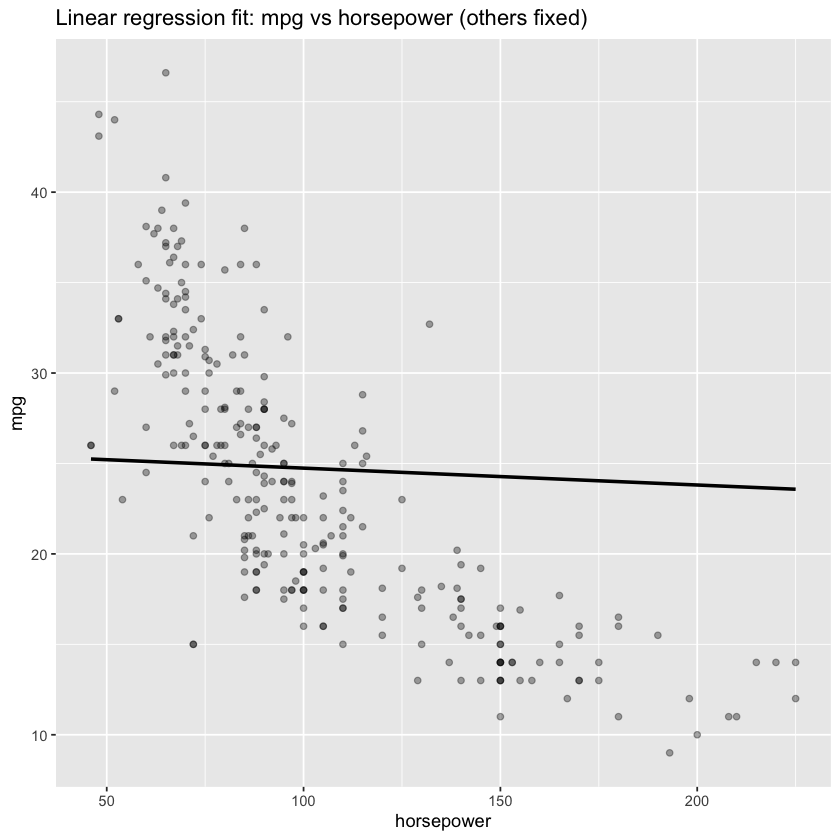

In [5]:
grid_lm <- tibble(
  horsepower = seq(min(train$horsepower), max(train$horsepower), length.out = 200),
  weight = median(train$weight),
  year = median(train$year)
) %>%  mutate(mpg_hat = predict(lm_fit, newdata =.))

ggplot(train, aes(horsepower, mpg)) +
  geom_point(alpha = 0.35) +
  geom_line(data = grid_lm, aes(horsepower, mpg_hat), linewidth = 1) +
  labs(title = "Linear regression fit: mpg vs horsepower (others fixed)")

### 1.4 Evaluate prediction on test set

In [6]:
test <- test |>
  mutate(mpg_hat = predict(lm_fit, newdata = test),
         resid = mpg - mpg_hat)

rmse <- sqrt(mean((test$mpg - test$mpg_hat)^2))
rmse

[1] 3.45108

### 1.5 Fitted vs actual (test)

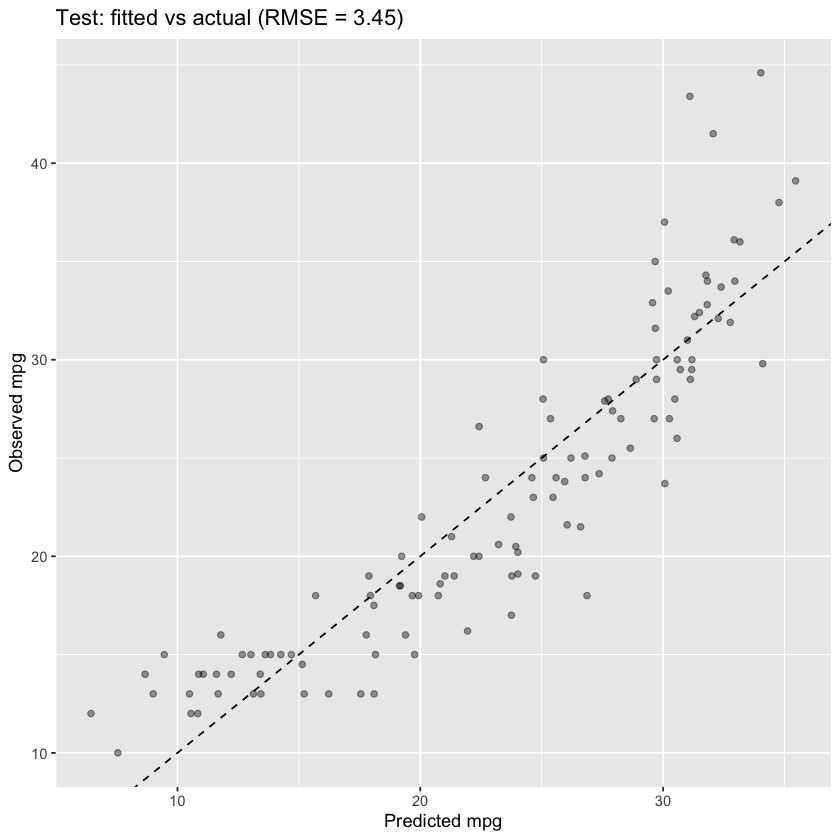

In [7]:
ggplot(test, aes(mpg_hat, mpg)) +
  geom_point(alpha = 0.4) +
  geom_abline(slope = 1, intercept = 0, linetype = 2) +
  labs(title = paste0("Test: fitted vs actual (RMSE = ", round(rmse, 2), ")"),
       x = "Predicted mpg", y = "Observed mpg")

### 1.6 Diagnostics

Residuals vs fitted and residual distribution.

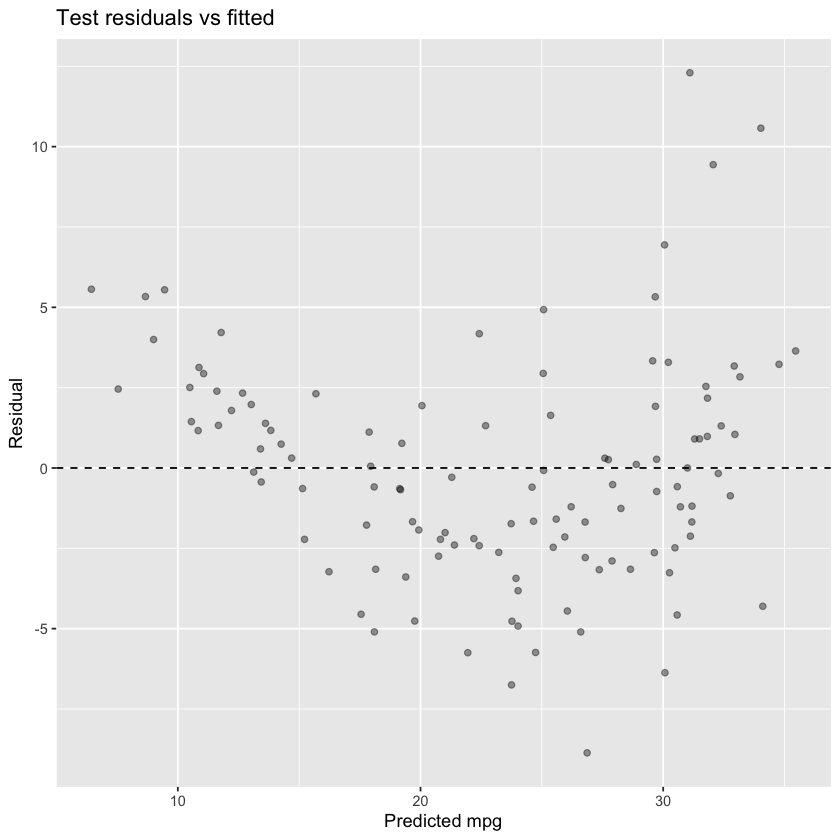

In [8]:
ggplot(test, aes(mpg_hat, resid)) +
  geom_point(alpha = 0.4) +
  geom_hline(yintercept = 0, linetype = 2) +
  labs(title = "Test residuals vs fitted", x = "Predicted mpg", y = "Residual")

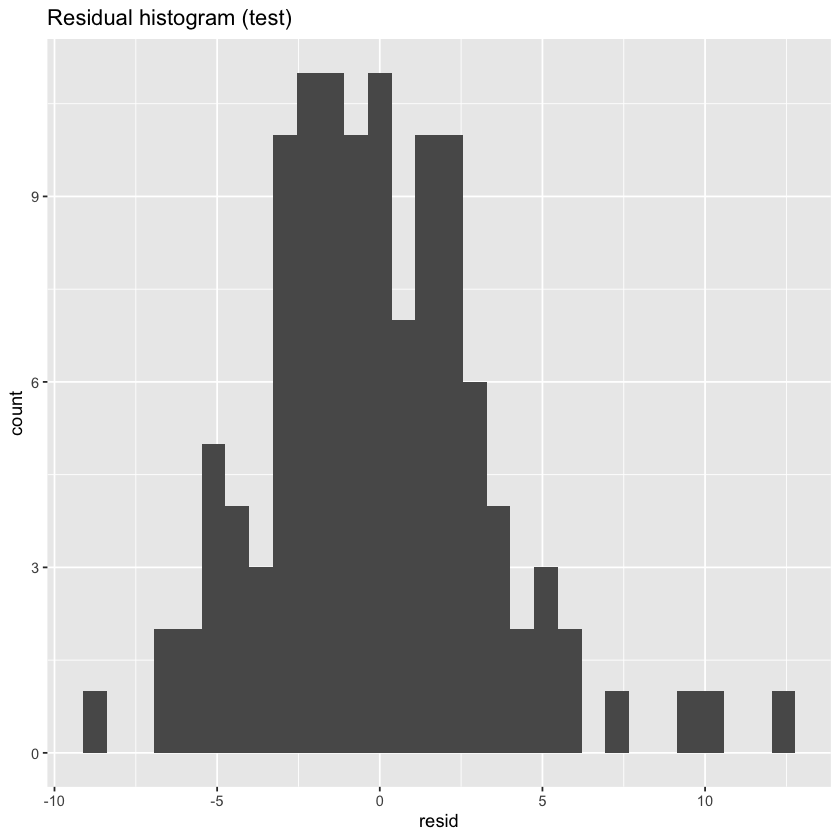

In [9]:
ggplot(test, aes(resid)) +
  geom_histogram(bins = 30) +
  labs(title = "Residual histogram (test)")

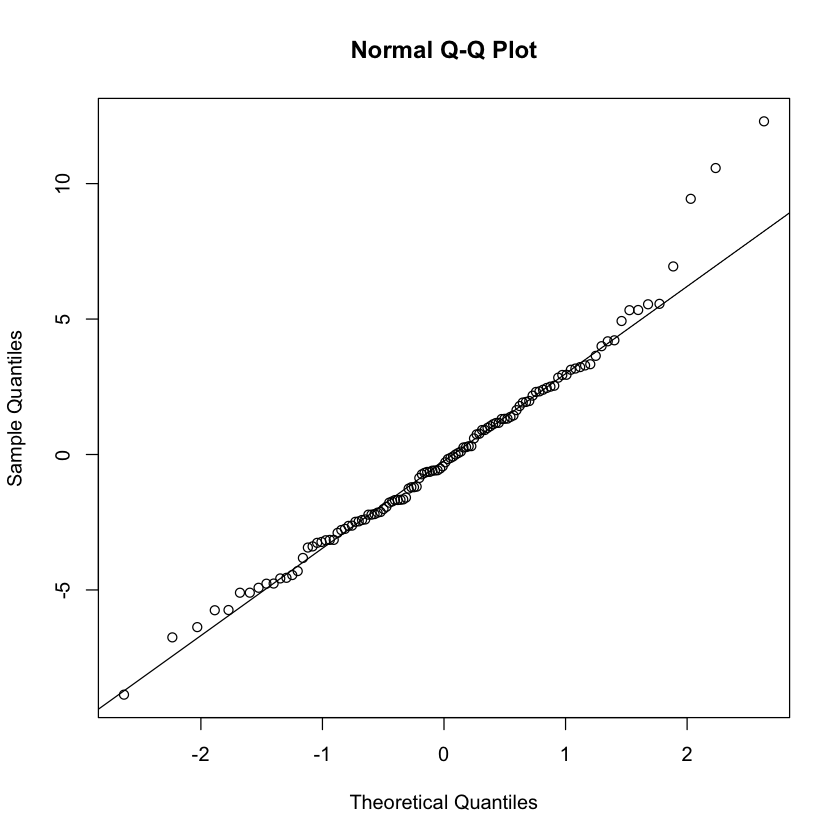

In [10]:
qqnorm(test$resid); qqline(test$resid)

### 2 Logistic Regression 

We use `Default` and predict `default`.

In [11]:
df_def <- Default |>
  as_tibble() |>
  mutate(default01 = ifelse(default == "Yes", 1, 0))

glimpse(df_def)
mean(df_def$default01)  # base rate

Rows: 10,000
Columns: 5
$ default   <fct> No, No, No, No, No, No, No, No, No, No, No, No, No, No, No, …
$ student   <fct> No, Yes, No, No, No, Yes, No, Yes, No, No, Yes, Yes, No, No,…
$ balance   <dbl> 729.5265, 817.1804, 1073.5492, 529.2506, 785.6559, 919.5885,…
$ income    <dbl> 44361.625, 12106.135, 31767.139, 35704.494, 38463.496, 7491.…
$ default01 <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


[1] 0.0333

### 2.1 Train/test split

In [12]:
n <- nrow(df_def)
idx_train <- sample.int(n, size = floor(0.7 * n))
train <- df_def[idx_train, ]
test  <- df_def[-idx_train, ]

### 2.2 Fit logistic model

In [13]:
log_fit <- glm(default01 ~ balance + income, data = train, family = binomial)
summary(log_fit)


Call:
glm(formula = default01 ~ balance + income, family = binomial, 
    data = train)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.209e+01  5.444e-01 -22.214  < 2e-16 ***
balance      5.863e-03  2.809e-04  20.872  < 2e-16 ***
income       2.605e-05  6.036e-06   4.316 1.59e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 2064  on 6999  degrees of freedom
Residual deviance: 1064  on 6997  degrees of freedom
AIC: 1070

Number of Fisher Scoring iterations: 8


### 2.3 Visualize fitted probability curve vs balance 

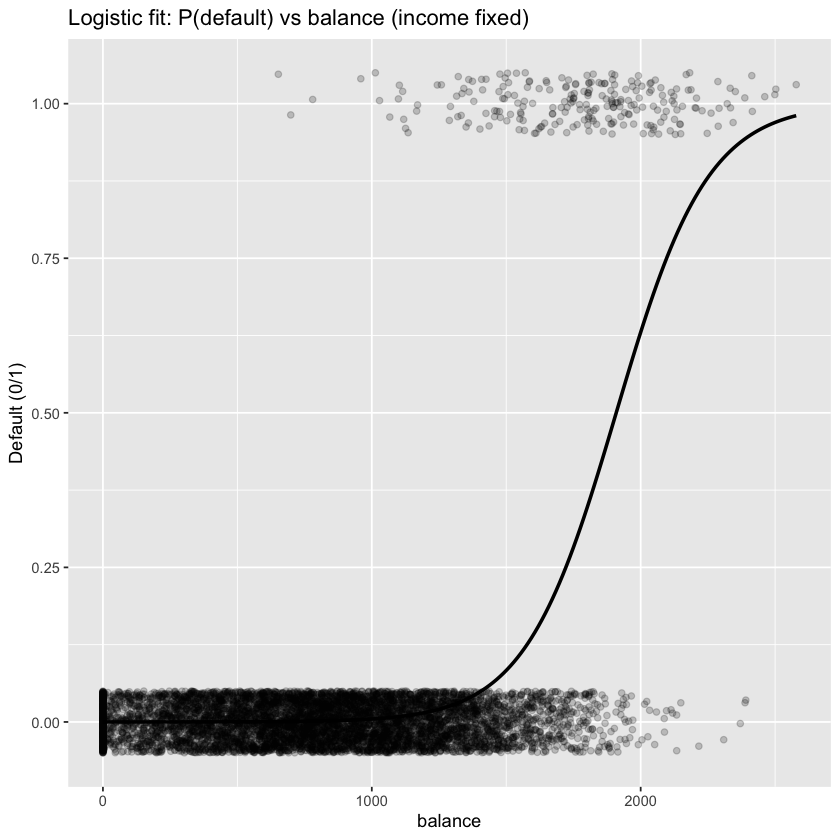

In [14]:
grid <- tibble(
  balance = seq(min(train$balance), max(train$balance), length.out = 200),
  income  = median(train$income)
) %>%
  mutate(prob = predict(log_fit, newdata = ., type = "response"))

ggplot(train, aes(balance, default01)) +
  geom_jitter(height = 0.05, alpha = 0.2) +
  geom_line(data = grid, aes(balance, prob), linewidth = 1) +
  labs(title = "Logistic fit: P(default) vs balance (income fixed)",
       y = "Default (0/1)")

### 2.4 Predicted probabilities on test set

In [15]:
test <- test |>
  mutate(p_hat = predict(log_fit, newdata = test, type = "response"))

### 2.5 ROC curve + AUC (test)

In [16]:
roc_obj <- roc(response = test$default01, predictor = test$p_hat, quiet = TRUE)
auc_val <- as.numeric(auc(roc_obj))
auc_val

[1] 0.9364788

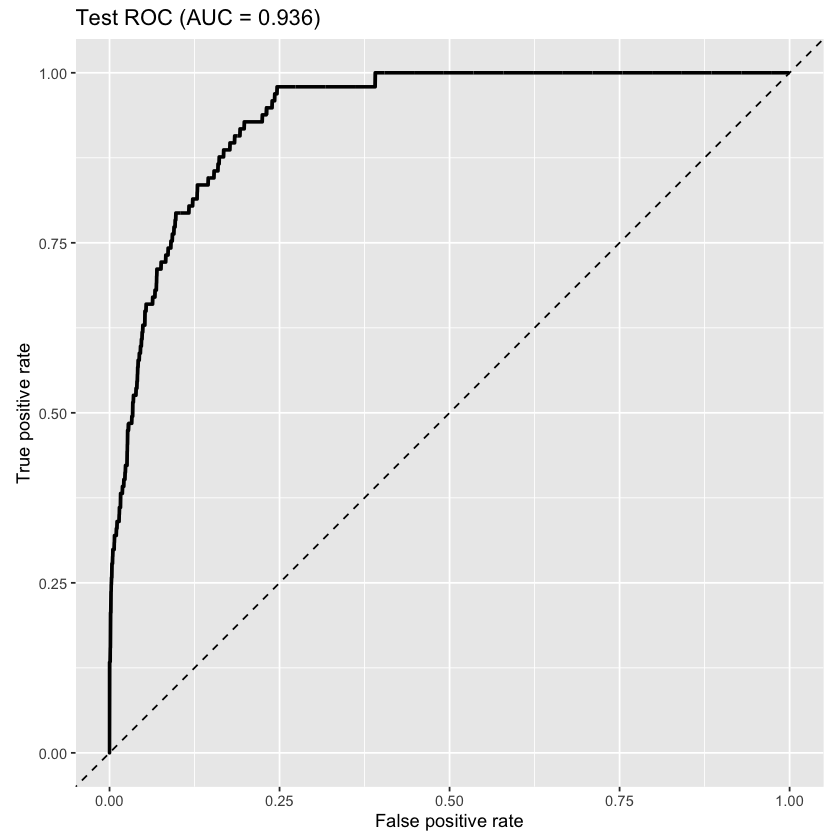

In [17]:
roc_df <- tibble(
  fpr = 1 - roc_obj$specificities,
  tpr = roc_obj$sensitivities
)

ggplot(roc_df, aes(fpr, tpr)) +
  geom_line(linewidth = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = 2) +
  coord_equal() +
  labs(title = paste0("Test ROC (AUC = ", round(auc_val, 3), ")"),
       x = "False positive rate", y = "True positive rate")

### 2.7 Binned residual plot 

Use response residuals $r_i = y_i - \hat p_i$.

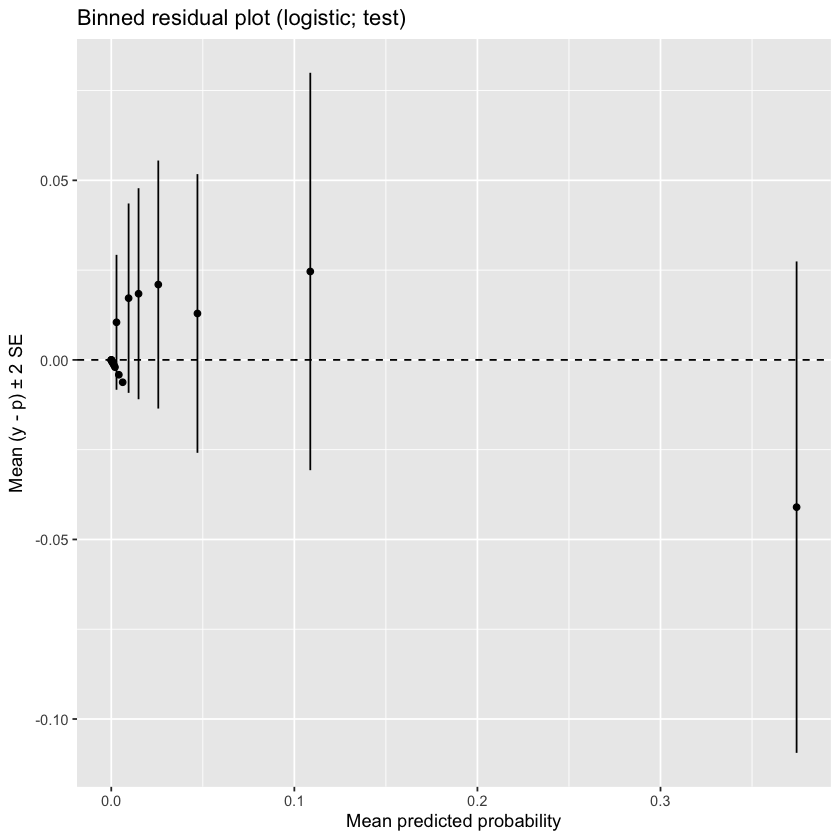

In [19]:
binned <- test |>
  mutate(resid = default01 - p_hat,
         bin = ntile(p_hat, 20)) |>
  group_by(bin) |>
  summarise(
    mean_phat = mean(p_hat),
    mean_resid = mean(resid),
    se = sd(resid) / sqrt(n()),
    .groups = "drop"
  )

ggplot(binned, aes(mean_phat, mean_resid)) +
  geom_hline(yintercept = 0, linetype = 2) +
  geom_point() +
  geom_errorbar(aes(ymin = mean_resid - 2*se, ymax = mean_resid + 2*se),
                width = 0) +
  labs(title = "Binned residual plot (logistic; test)",
       x = "Mean predicted probability", y = "Mean (y - p) ± 2 SE")

### 3 Decision Tree 

We use the same `Default` train/test split and compare models.


Classification tree:
rpart(formula = factor(default01) ~ balance + income + student, 
    data = train, method = "class", control = rpart.control(cp = 0.001))

Variables actually used in tree construction:
[1] balance income 

Root node error: 236/7000 = 0.033714

n= 7000 

         CP nsplit rel error  xerror     xstd
1 0.1652542      0   1.00000 1.00000 0.063988
2 0.0487288      1   0.83475 0.83475 0.058630
3 0.0105932      3   0.73729 0.77119 0.056416
4 0.0063559      5   0.71610 0.77542 0.056567
5 0.0042373      7   0.70339 0.79661 0.057313
6 0.0021186      9   0.69492 0.81356 0.057903
7 0.0010000     11   0.69068 0.84746 0.059062


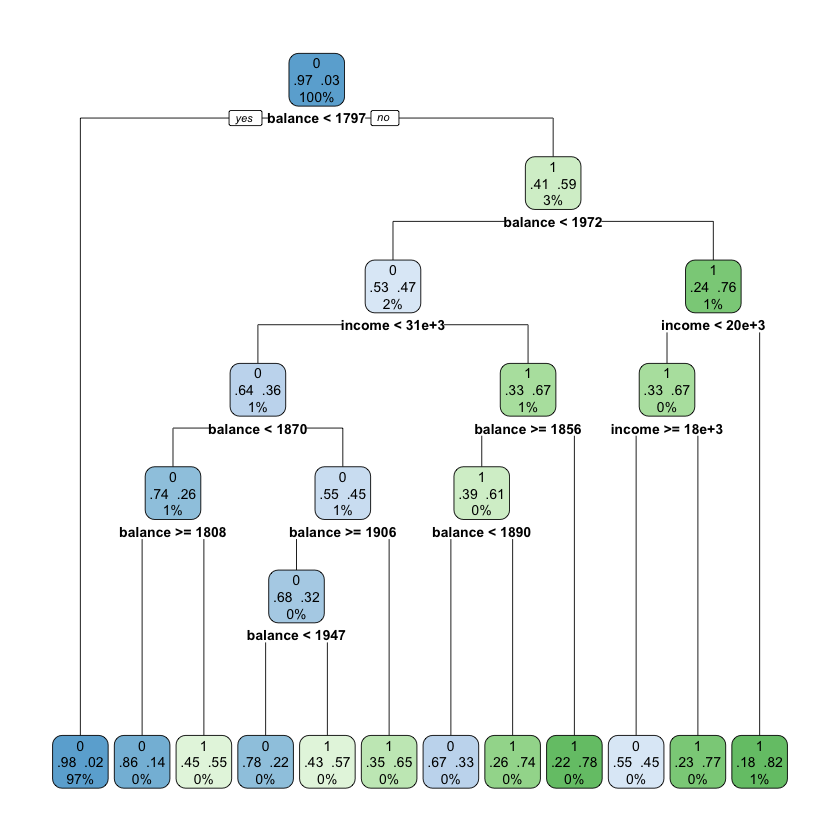

In [20]:
tree_fit <- rpart(
  factor(default01) ~ balance + income + student,
  data = train,
  method = "class",
  control = rpart.control(cp = 0.001)
)

rpart.plot(tree_fit, extra = 104, fallen.leaves = TRUE)
printcp(tree_fit)

### 3.2 Tree diagnostic: CV error vs cp

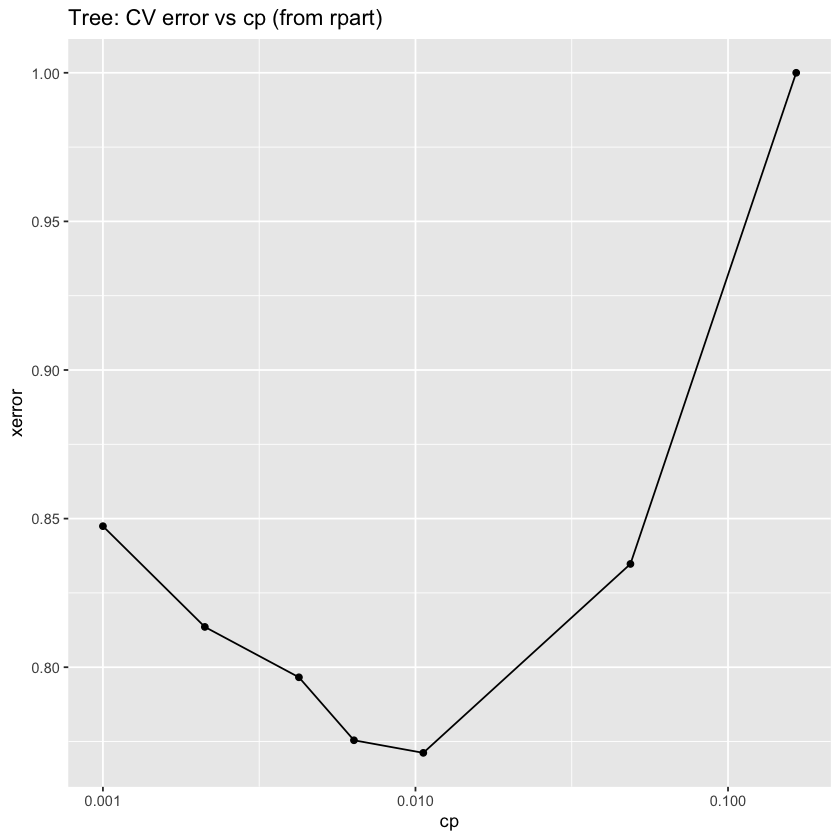

In [21]:
cp_tbl <- as_tibble(tree_fit$cptable)
ggplot(cp_tbl, aes(CP, xerror)) +
  geom_line() + geom_point() +
  scale_x_log10() +
  labs(title = "Tree: CV error vs cp (from rpart)", x = "cp", y = "xerror")

### 3.3 Tree: test predictions + ROC

In [22]:
tree_prob <- predict(tree_fit, newdata = test, type = "prob")[, "1"]
tree_pred <- as.integer(tree_prob >= 0.5)

table(pred = tree_pred, truth = test$default01)

roc_tree <- roc(test$default01, tree_prob, quiet = TRUE)
auc_tree <- as.numeric(auc(roc_tree))
auc_tree

    truth
pred    0    1
   0 2879   68
   1   24   29

[1] 0.6795938

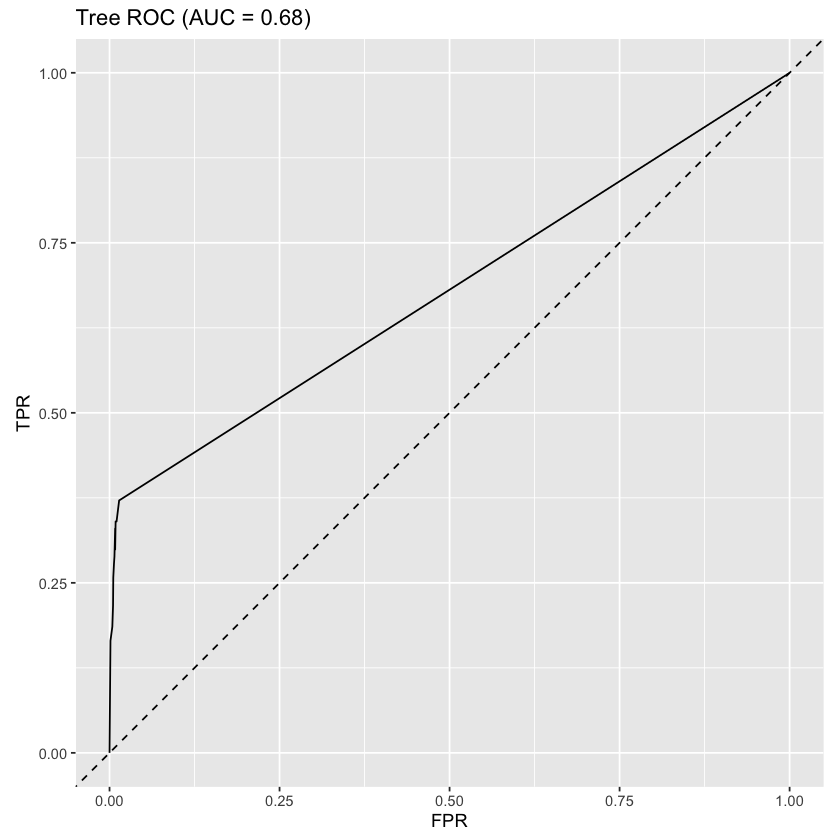

In [23]:
roc_tree_df <- tibble(
  fpr = 1 - roc_tree$specificities,
  tpr = roc_tree$sensitivities
)

ggplot(roc_tree_df, aes(fpr, tpr)) +
  geom_line() +
  geom_abline(slope = 1, intercept = 0, linetype = 2) +
  coord_equal() +
  labs(title = paste0("Tree ROC (AUC = ", round(auc_tree, 3), ")"),
       x = "FPR", y = "TPR")

### 4 Random forest


We use the same `Default` train/test split and compare models.

In [24]:
rf_fit <- randomForest(
  factor(default01) ~ balance + income + student,
  data = train,
  ntree = 500,
  mtry = 2,
  importance = TRUE
)

rf_fit


Call:
 randomForest(formula = factor(default01) ~ balance + income +      student, data = train, ntree = 500, mtry = 2, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 2

        OOB estimate of  error rate: 3.1%
Confusion matrix:
     0  1 class.error
0 6694 70  0.01034891
1  147 89  0.62288136

### 4.1 RF diagnostics: OOB error and variable importance

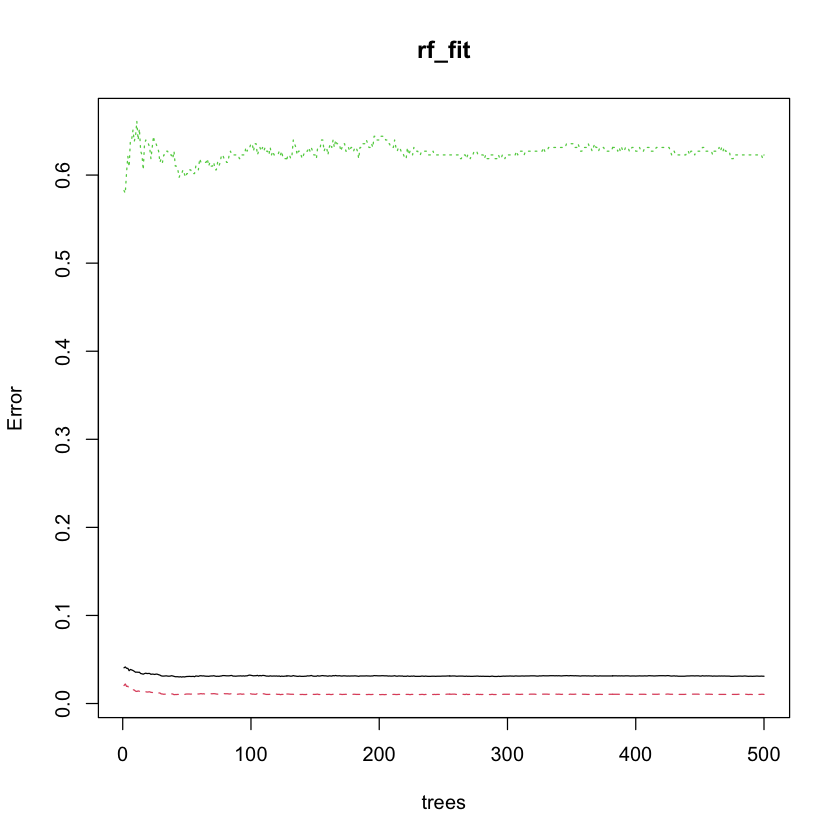

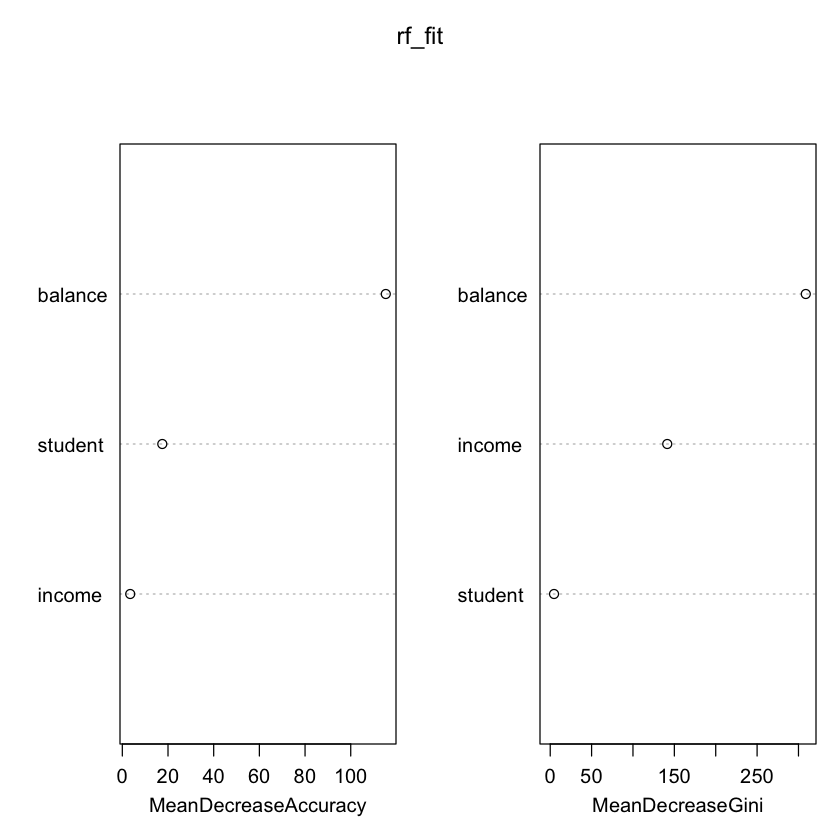

In [25]:
plot(rf_fit)     # OOB error vs trees
varImpPlot(rf_fit)

### 4.2 test ROC

In [26]:
rf_prob <- predict(rf_fit, newdata = test, type = "prob")[, "1"]
roc_rf <- roc(test$default01, rf_prob, quiet = TRUE)
auc_rf <- as.numeric(auc(roc_rf))
auc_rf

[1] 0.8824217

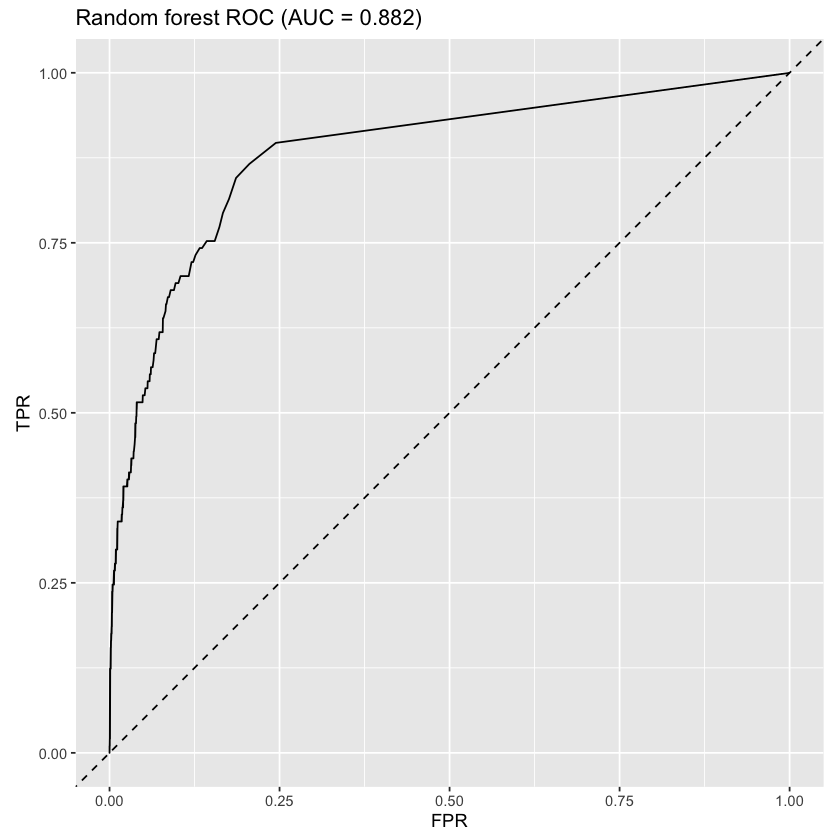

In [27]:
roc_rf_df <- tibble(
  fpr = 1 - roc_rf$specificities,
  tpr = roc_rf$sensitivities
)

ggplot(roc_rf_df, aes(fpr, tpr)) +
  geom_line() +
  geom_abline(slope = 1, intercept = 0, linetype = 2) +
  coord_equal() +
  labs(title = paste0("Random forest ROC (AUC = ", round(auc_rf, 3), ")"),
       x = "FPR", y = "TPR")

### 4.3 Compare ROC curves (logistic vs tree vs RF)

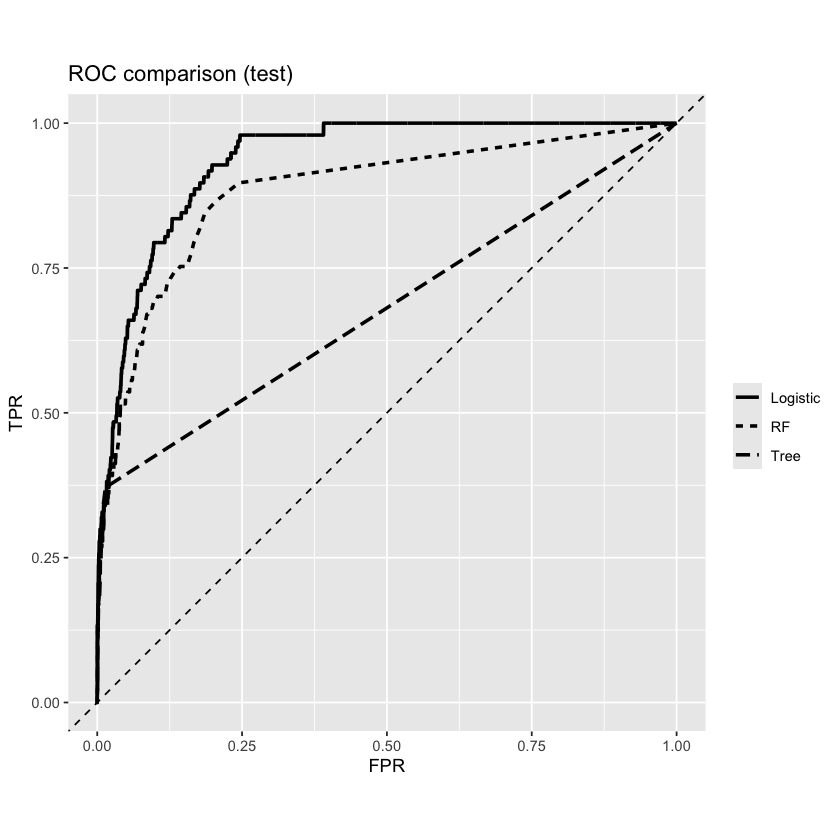

In [28]:
roc_log <- roc(test$default01, test$p_hat, quiet = TRUE)

roc_comp <- bind_rows(
  tibble(fpr = 1 - roc_log$specificities,  tpr = roc_log$sensitivities,  model = "Logistic"),
  tibble(fpr = 1 - roc_tree$specificities, tpr = roc_tree$sensitivities, model = "Tree"),
  tibble(fpr = 1 - roc_rf$specificities,   tpr = roc_rf$sensitivities,   model = "RF")
)

ggplot(roc_comp, aes(fpr, tpr, linetype = model)) +
  geom_line(linewidth = 1) +
  geom_abline(slope = 1, intercept = 0, linetype = 2) +
  coord_equal() +
  labs(title = "ROC comparison (test)", x = "FPR", y = "TPR", linetype = "")

### 4.4 Cross-validation 
AUC-based k-fold CV for logistic regression and CP selection for trees.

In [29]:
cv_auc_logistic <- function(df, k = 5) {
  n <- nrow(df)
  folds <- sample(rep(1:k, length.out = n))
  aucs <- numeric(k)

  for (j in 1:k) {
    tr <- df[folds != j, ]
    va <- df[folds == j, ]

    fit <- glm(default01 ~ balance + income, data = tr, family = binomial)
    p   <- predict(fit, newdata = va, type = "response")
    aucs[j] <- as.numeric(auc(roc(va$default01, p, quiet = TRUE)))
  }
  mean(aucs)
}

cv_auc_logistic(train, k = 5)

[1] 0.9535946

### 4.5 Tree complexity selection via `cptable` (choose cp minimizing CV error)

In [30]:
cp_tbl <- as_tibble(tree_fit$cptable) |>
  mutate(row = row_number())

best_row <- which.min(cp_tbl$xerror)
best_cp <- cp_tbl$CP[best_row]
best_cp

[1] 0.01059322

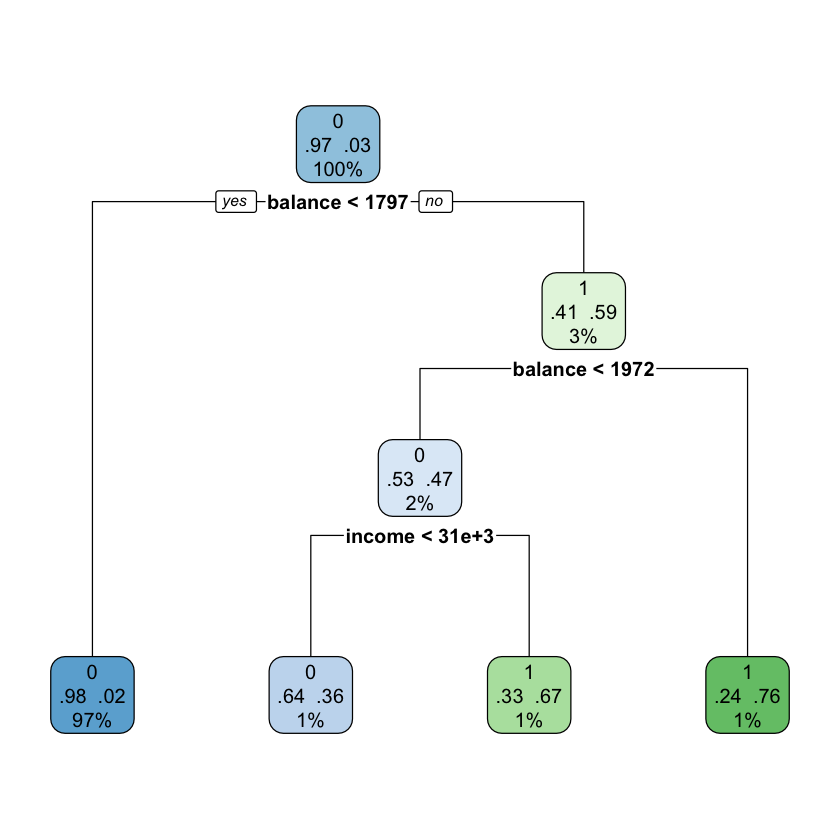

In [31]:
tree_pruned <- prune(tree_fit, cp = best_cp)
rpart.plot(tree_pruned, extra = 104, fallen.leaves = TRUE)

## Exercise

### Exercise 1: Linear regression and prediction error (Auto data)

#### (a) Data preparation and train/test split

Convert the dataset to a tibble, remove missing values, and split the data into **70% training** and **30% testing**.

In [ ]:
# df_auto <- ___ |>
#   ___ |>
#   ___

# n <- ___
# idx_train <- ___
#
# train <- ___
# test  <- ___


#### (b) Fit a linear regression model

We fit a linear regression model using the training data.

In [ ]:
# lm_fit <- ___


#### (c) Training & test MSE

Compute the **mean squared error (MSE)** on both the training set and the test set.

In [ ]:
# train_pred <- ___
# mse_train <- ___
# mse_train


In [ ]:
# test_pred <- ___
# mse_test <- ___
# mse_test


#### (e) Fitted vs actual values (test set)

Create a scatter plot comparing predicted and observed `mpg` values on the test set.

In [ ]:
# test_plot <- test |>
#   ___


In [ ]:
# ggplot(test_plot, aes(___, ___)) +
#   geom_point(alpha = 0.6) +
#   geom_abline(slope = 1, intercept = 0)


### Exercise 2 Logistic regression and ROC analysis (Default)

In this part, we predict whether a customer defaults on credit.

- **Response:** `default01` (1 = Yes, 0 = No)  
- **Covariates:** `balance`, `income`  

Because the classes are imbalanced, we evaluate performance using **ROC curves and AUC** instead of accuracy.


#### (a) Data preparation and train/test split

Create a binary response variable and split the data into **70% training** and **30% testing**.

In [ ]:
# df_def <- ___ |>
#   ___ |>
#   ___


In [ ]:
# n <- ___
# idx_train <- ___
#
# train <- ___
# test  <- ___


#### (b) Fit a logistic regression model

Fit a logistic regression model using `balance` and `income` as predictors.

In [ ]:
# log_fit <- glm(
#   ___ ~ ___ + ___,
#   data = ___,
#   family = ___
# )


#### (c) Predicted probabilities and ROC/AUC

Compute predicted probabilities on the test set and evaluate performance using ROC and AUC.

In [ ]:
# test <- test |>
#   mutate(p_hat = ___)


In [ ]:
# roc_obj <- roc(
#   response = ___,
#   predictor = ___,
#   quiet = TRUE
# )
#
# auc_val <- ___
# auc_val


#### (d) ROC curve visualization

In [ ]:
# roc_df <- tibble(
#   fpr = ___,
#   tpr = ___
# )


In [ ]:
# ggplot(roc_df, aes(___, ___)) +
#   geom_line() +
#   geom_abline(slope = 1, intercept = 0, linetype = "dashed")


#### (e) Classification using a threshold

Compare classification results using probability thresholds **0.5** and **0.2**.

In [ ]:
# pred_05 <- ___
# pred_02 <- ___


In [ ]:
# table(pred = pred_05, truth = ___)
# table(pred = pred_02, truth = ___)


### Exercise 3 Model comparison: Tree vs logistic regression

We now compare logistic regression with a **classification tree**.

- **Response:** `default01`  
- **Covariates:** `balance`, `income`, `student`  

The goal is to contrast **interpretability** and **predictive performance**.


#### (a) Fit a classification tree

In [ ]:
# tree_fit <- rpart(
#   ___ ~ ___ + ___ + ___,
#   data = ___,
#   method = ___,
#   control = rpart.control(cp = ___)
# )


#### (b) Plot the tree

In [ ]:
# rpart.plot(
#   tree_fit,
#   extra = ___,
#   fallen.leaves = ___
# )


#### (c) Tree-based prediction and AUC

In [ ]:
# tree_prob <- ___


In [ ]:
# roc_tree <- roc(
#   ___,
#   ___,
#   quiet = TRUE
# )
#
# auc_tree <- ___
# auc_tree


#### (d) ROC comparison

In [ ]:
# roc_log <- ___


In [ ]:
# plot(roc_log)
# plot(roc_tree, add = TRUE)
